### Desicon Tree (cây quyết định):
- Decision Tree là mô hình Machine Learning học cách đặt một chuỗi câu hỏi về dữ liệu, từ đó đưa ra dự đoán.
- khác với các thuật toán khác thì cái này nó sẽ duyệt qua tree, trả lời câu hỏi yes/no để rẻ nhánh
- Các thành phần: 

| Thành phần  |	Ý nghĩa |
|---|---|
| Root Node	Nút gốc | câu hỏi đầu tiên |
| Decision Node | Nút đặt câu hỏi để chia dữ liệu |
| Branch / Edge | Nhánh tương ứng với câu trả lời |
| Leaf Node	| Nút lá, chứa kết quả dự đoán |
| Depth	Độ sâu | số cạnh trên đường dài nhất từ gốc đến lá |
  

- Và nó có thể chia nhánh theo các cái sau  

| Tiêu chí  | Ý nghĩa |
|---|---|
| Accuracy | Đánh giá độ chính xác phân loại sau khi chia |
| Gini Impurity	| Đo mức độ pha trộn các class |
| Entropy |	Đo độ hỗn loạn / không chắc chắn của nhãn |

### Gini Impurity
Công thức:
$$\boxed{Gini=1-\sum_{i=1}^{k}p_i^2}$$

Trong đó \(p_i\) là tỷ lệ mẫu thuộc class \(i\).
Ví dụ nhóm có 5 Spam và 5 Ham:
$$Gini=1-(0.5^2+0.5^2)=0.5$$

Nếu nhóm có 10 Spam và 0 Ham:
$$Gini=1-(1^2+0^2)=0$$

Gini càng thấp thì nhóm càng thuần nhất. Gini bằng 0 nghĩa là tất cả mẫu trong nhóm thuộc cùng một class.
Entropy
Công thức:
$$\boxed{H=-\sum_{i=1}^{k}p_i\log_2(p_i)}$$

Với 5 Spam và 5 Ham:
$$H=-(0.5\log_2 0.5+0.5\log_2 0.5)=1$$

Với 10 Spam và 0 Ham:
$$H=0$$

Quy ước \(0\log_2 0=0\).
Entropy cũng đo mức độ pha trộn class: Entropy càng thấp thì nhóm càng thuần nhất.

### Entropy — Độ không chắc chắn

Entropy đo mức độ không chắc chắn về class của một mẫu trong nhóm.
$$
H=-\sum_{i=1}^{k}p_i\log_2(p_i)
$$

ví dụ:  
<pre>
Vẫn với ba nhóm trên:
Nhóm	Spam / Ham	 Entropy
A	      5 / 5	      1.000
B	      9 / 1	      0.469
C	      10 / 0	  0.000
</pre>

Ý nghĩa:
- Entropy = 1: Với hai class cân bằng, rất khó biết mẫu thuộc class nào.
- Entropy gần 0: Một class chiếm ưu thế rõ rệt.
- Entropy = 0: Tất cả mẫu cùng class, không còn sự không chắc chắn về nhãn.


**Mục tiêu: Chọn phép chia có Entropy trung bình có trọng số nhỏ nhất.**  
**Lưu ý: Entropy có thể lớn hơn 1 nếu bài toán có nhiều hơn hai class.**

### IG (information gain)
3. Information Gain (IG) — Lượng thông tin thu được
Khác với Gini và Entropy đo độ hỗn loạn, Information Gain đo xem sau khi chia, Entropy giảm được bao nhiêu.
Công thức:
$$
\boxed{IG=H(parent)-H(children)}
$$

Trong đó \(H(children)\) là Entropy trung bình có trọng số của các nhánh con.
Ví dụ ban đầu có 10 email, 5 Spam và 5 Ham:
$$
H(parent)=1
$$  
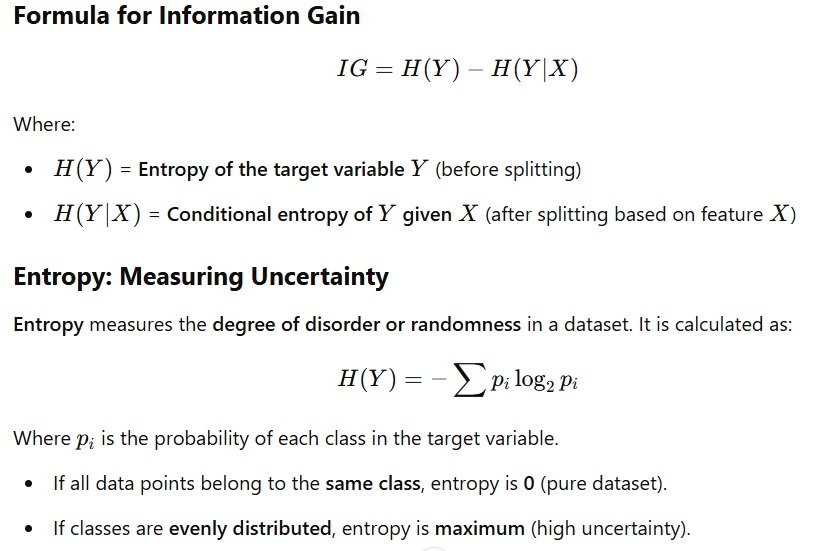

	Các Tiêu Chí Chọn của các tham số của nó |
| Metric |	Đo cái gì? |Ý nghĩa |
|---|---|---|
| Gini | Mức độ pha trộn class | Nhỏ nhất |
| Entropy |	Mức độ không chắc chắn về nhãn | Nhỏ nhất |
| Information Gain |	Mức giảm Entropy sau chia |	Lớn nhất |
| Accuracy |	Tỷ lệ phân loại đúng |	Lớn nhất |    

| Cách nhớ đơn giản nhất:
- Gini: Nhóm có bị trộn class nhiều không?
- Entropy: Ta có đang không chắc mẫu thuộc class nào không?
- Information Gain: Sau khi chia, ta giảm được bao nhiêu sự không chắc chắn?
- Accuracy: Sau khi chia, ta phân loại đúng được bao nhiêu mẫu?

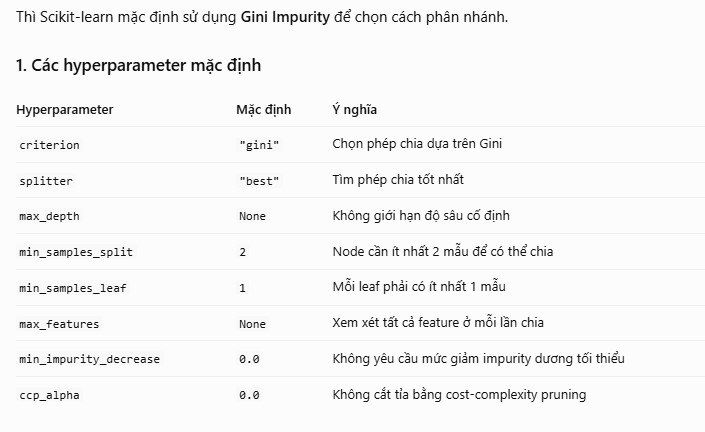

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Chọn phép chia bằng Gini
model_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3
)

# Chọn phép chia bằng Entropy
model_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3
)

# Dùng log loss (cùng tiêu chí phân chia dựa trên entropy)
model_logloss = DecisionTreeClassifier(
    criterion="log_loss",
    max_depth=3
)